#Análisis histórico del S&P 500 (1950–2025)

Este proyecto analiza la evolución del índice **S&P 500** desde 1950 hasta 2025, utilizando datos históricos de precios de cierre.  
Se exploran los rendimientos, la volatilidad y las tendencias por década para entender cómo ha cambiado el mercado a lo largo del tiempo.

Herramientas utilizadas en el proyecto:
- Python (pandas, numpy, matplotlib, seaborn)
- Google Colab


In [2]:
import kagglehub

# Descargar la última versión del dataset del S&P 500
path = kagglehub.dataset_download("benjibb/sp500-since-1950")

print("Path to dataset files:", path)


100%|██████████| 277k/277k [00:00<00:00, 64.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/benjibb/sp500-since-1950/versions/1


In [3]:
import os

# Ver todos los archivos dentro de la carpeta descargada
print("Archivos dentro de la carpeta Kaggle:")
print(os.listdir(path))


Archivos dentro de la carpeta Kaggle:
['GSPC.csv']


In [4]:
import pandas as pd

file_path = os.path.join(path, "GSPC.csv")
data = pd.read_csv(file_path)

print("Primeras filas del dataset:")
print(data.head())


Primeras filas del dataset:
         Date   Open   High    Low  Close  Adj Close   Volume
0  1950-01-03  16.66  16.66  16.66  16.66      16.66  1260000
1  1950-01-04  16.85  16.85  16.85  16.85      16.85  1890000
2  1950-01-05  16.93  16.93  16.93  16.93      16.93  2550000
3  1950-01-06  16.98  16.98  16.98  16.98      16.98  2010000
4  1950-01-09  17.08  17.08  17.08  17.08      17.08  2520000


In [5]:
# =========================================
# 1. Limpieza y preparación de los datos
# =========================================

# Convertir la columna de fecha al formato datetime
data['Date'] = pd.to_datetime(data['Date'])

# Ordenar por fecha (por si acaso)
data = data.sort_values('Date')

# Crear columnas adicionales
data['Year'] = data['Date'].dt.year
data['Decade'] = (data['Year'] // 10) * 10

# Ver rango de fechas y valores faltantes
print("Rango temporal:", data['Date'].min(), "→", data['Date'].max())
print("Valores faltantes por columna:\n", data.isnull().sum())


Rango temporal: 1950-01-03 00:00:00 → 2018-06-06 00:00:00
Valores faltantes por columna:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Year         0
Decade       0
dtype: int64


In [6]:
# =========================================
# 2. Cálculo de rendimientos
# =========================================

# Calcular rendimientos diarios
data['Daily_Return'] = data['Close'].pct_change()

# Calcular rendimientos anuales promedio (media de rendimientos diarios × 252)
annual_returns = data.groupby('Year')['Daily_Return'].mean() * 252 * 100

# Mostrar los primeros años
annual_returns.head()


,Daily_Return
Year,
1950,21.856180
1951,15.907923
1952,11.538412
1953,-6.422166
1954,37.639667


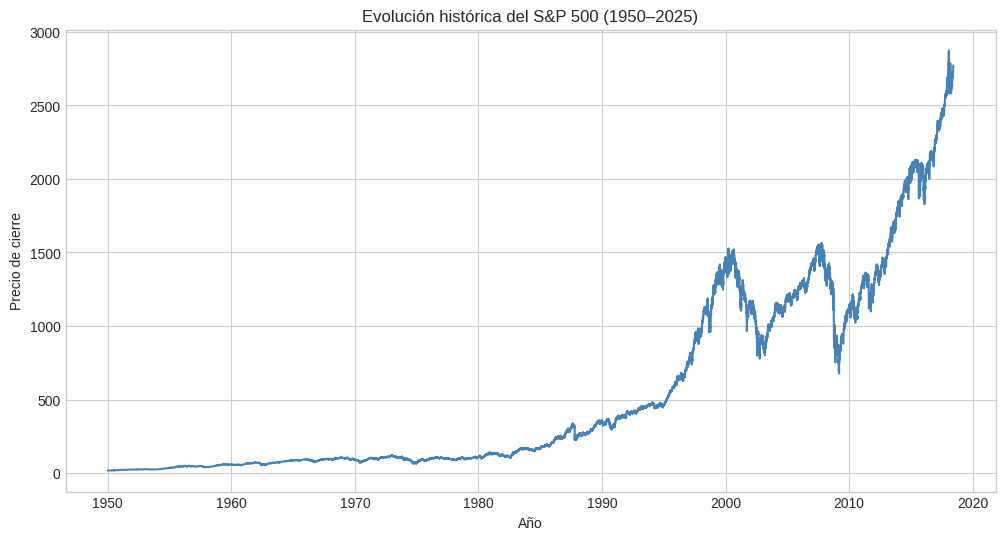

In [7]:
# =========================================
# 3. Gráfica del precio histórico
# =========================================

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'], color='steelblue')
plt.title("Evolución histórica del S&P 500 (1950–2025)")
plt.xlabel("Año")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.show()


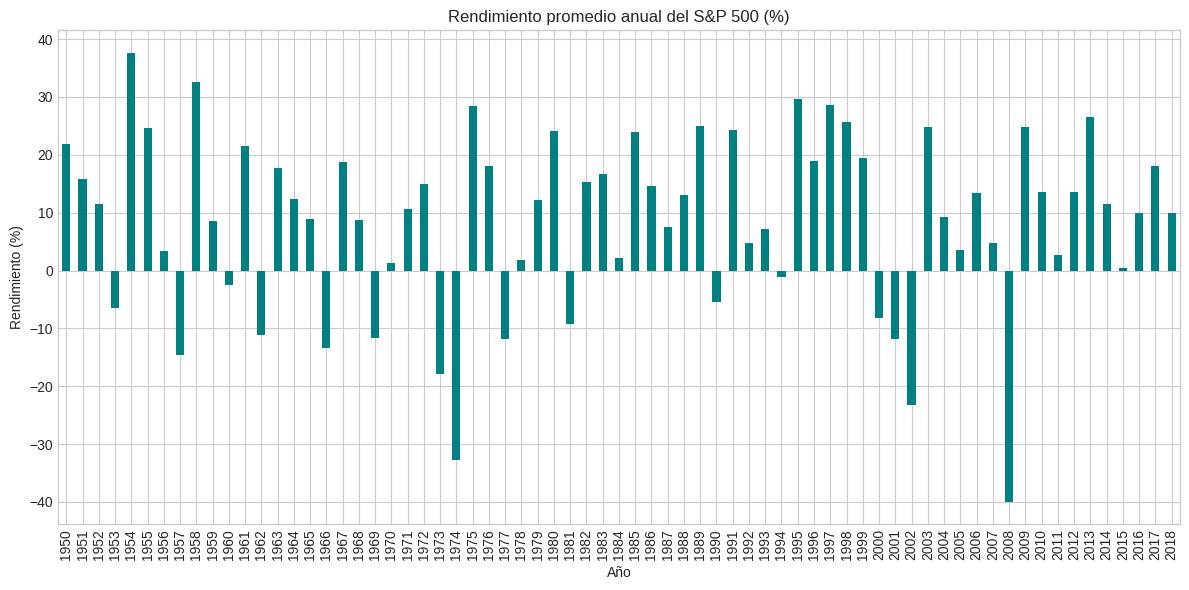

In [8]:
# =========================================
# 4️. Rendimientos anuales promedio
# =========================================

plt.figure(figsize=(12,6))
annual_returns.plot(kind='bar', color='teal')
plt.title("Rendimiento promedio anual del S&P 500 (%)")
plt.xlabel("Año")
plt.ylabel("Rendimiento (%)")
plt.tight_layout()
plt.show()


In [9]:
# =========================================
# 5. Análisis por década: rendimiento y volatilidad
# =========================================

import numpy as np
decade_summary = data.groupby('Decade')['Daily_Return'].agg(['mean','std'])
decade_summary['mean'] = decade_summary['mean'] * 252 * 100
decade_summary['std'] = decade_summary['std'] * np.sqrt(252) * 100
decade_summary.rename(columns={'mean':'Rendimiento medio anual (%)',
                               'std':'Volatilidad anual (%)'}, inplace=True)

print("Resumen por década:")
display(decade_summary)


Resumen por década:


,Rendimiento medio anual (%),Volatilidad anual (%)
Decade,,
1950,13.507590,11.461727
1960,4.872173,10.181925
1970,2.511327,13.605898
1980,13.326942,17.131783
1990,15.202659,14.099062
2000,-0.293723,22.228303
2010,11.931269,14.872164


/tmp/ipykernel_2859/1873120558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_summary.index, y='Volatilidad anual (%)',


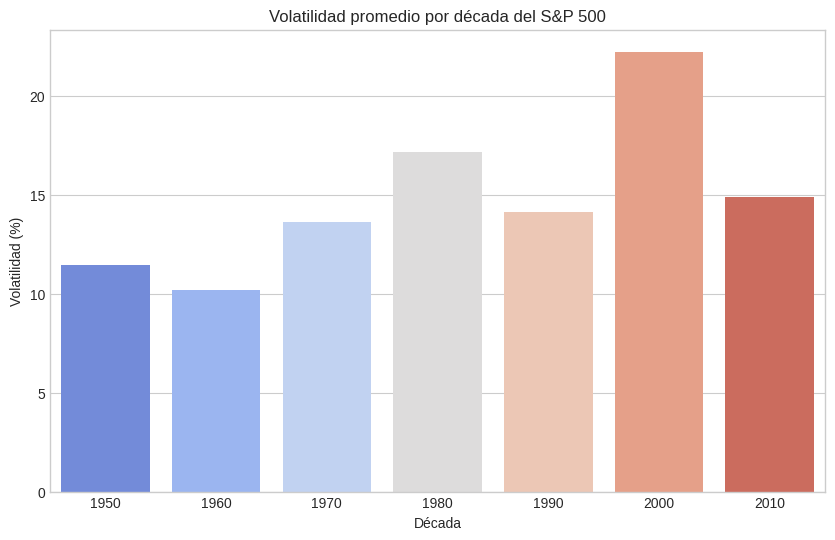

In [10]:
# =========================================
# 6. Gráfica de volatilidad por década
# =========================================

import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=decade_summary.index, y='Volatilidad anual (%)',
            data=decade_summary, palette='coolwarm')
plt.title("Volatilidad promedio por década del S&P 500")
plt.xlabel("Década")
plt.ylabel("Volatilidad (%)")
plt.show()


/tmp/ipykernel_2859/1511739887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_summary.index, y='Rendimiento medio anual (%)',


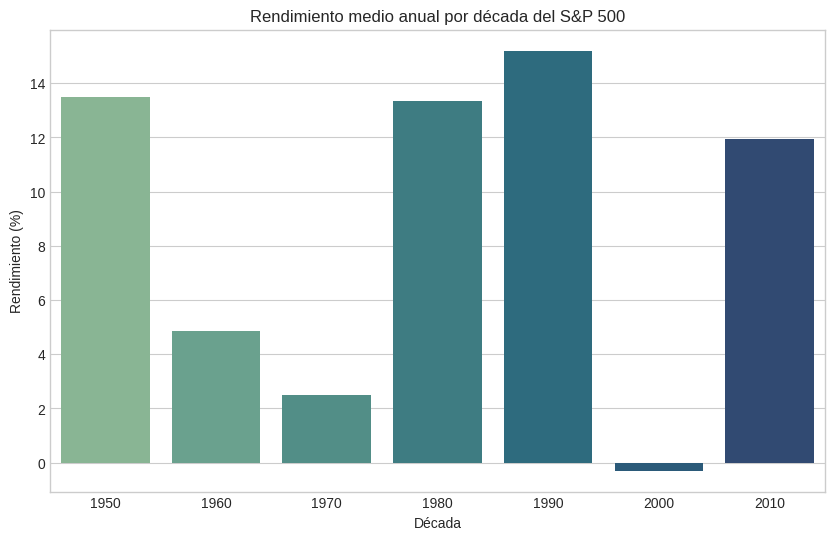

In [11]:
# =========================================
# 7. Gráfico del rendimiento promedio por década
# =========================================

plt.figure(figsize=(10,6))
sns.barplot(x=decade_summary.index, y='Rendimiento medio anual (%)',
            data=decade_summary, palette='crest')
plt.title("Rendimiento medio anual por década del S&P 500")
plt.xlabel("Década")
plt.ylabel("Rendimiento (%)")
plt.show()


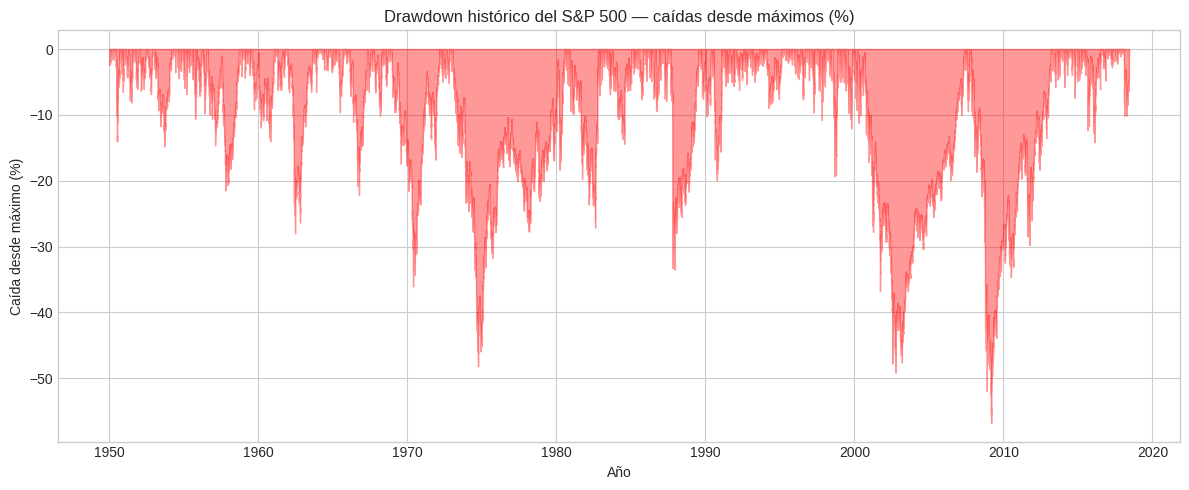

Mayor caída histórica: -56.8%
Fecha del peor momento: 2009-03-09


In [13]:
# =========================================
# 8. DRAWDOWN MÁXIMO HISTÓRICO
# =========================================

data['Rolling_Max'] = data['Close'].cummax()
data['Drawdown'] = (data['Close'] - data['Rolling_Max']) / data['Rolling_Max'] * 100

plt.figure(figsize=(12, 5))
plt.fill_between(data['Date'], data['Drawdown'], 0, color='red', alpha=0.4)
plt.title('Drawdown histórico del S&P 500 — caídas desde máximos (%)')
plt.xlabel('Año')
plt.ylabel('Caída desde máximo (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mayor caída histórica: {data['Drawdown'].min():.1f}%")
print(f"Fecha del peor momento: {data.loc[data['Drawdown'].idxmin(), 'Date'].date()}")

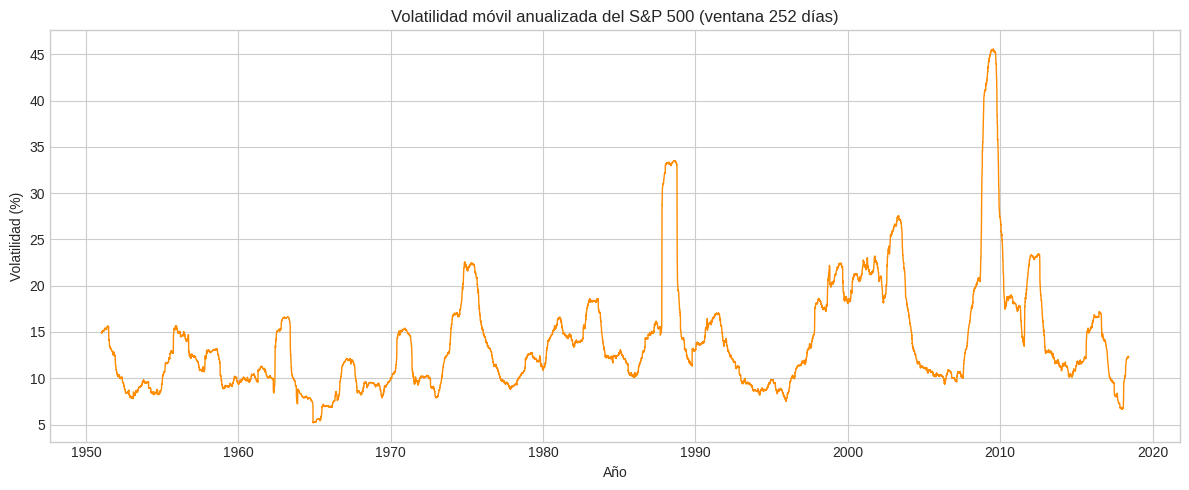

Volatilidad promedio histórica: 14.0%
Año más volátil: 2009


In [14]:
# =========================================
# 9. VOLATILIDAD MÓVIL (252 días = 1 año)
# =========================================

data['Volatilidad_252'] = data['Daily_Return'].rolling(252).std() * (252**0.5) * 100

plt.figure(figsize=(12, 5))
plt.plot(data['Date'], data['Volatilidad_252'], color='darkorange', linewidth=1)
plt.title('Volatilidad móvil anualizada del S&P 500 (ventana 252 días)')
plt.xlabel('Año')
plt.ylabel('Volatilidad (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Volatilidad promedio histórica: {data['Volatilidad_252'].mean():.1f}%")
print(f"Año más volátil: {data.loc[data['Volatilidad_252'].idxmax(), 'Year']}")

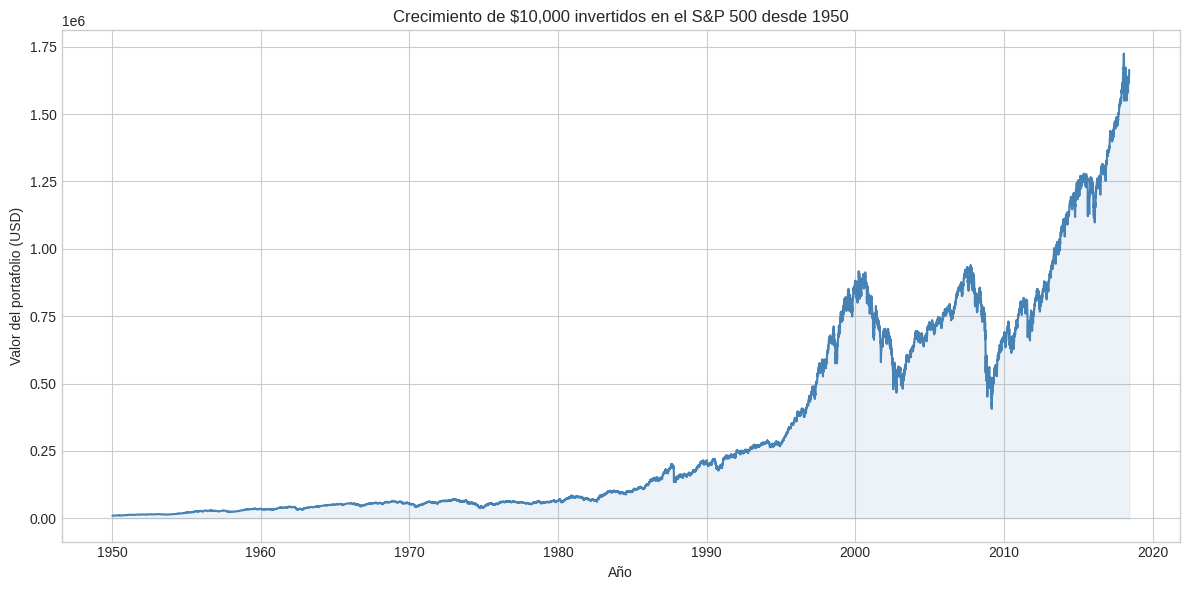

Inversión inicial:  $10,000
Valor actual:       $1,664,076
Multiplicador:      166x


In [15]:
# =========================================
# 10. SIMULACIÓN: ¿CUÁNTO CRECERÍA $10,000?
# =========================================

inversion_inicial = 10000
data['Valor_Portafolio'] = inversion_inicial * (1 + data['Daily_Return']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Valor_Portafolio'], color='steelblue', linewidth=1.5)
plt.fill_between(data['Date'], data['Valor_Portafolio'], alpha=0.1, color='steelblue')
plt.title('Crecimiento de $10,000 invertidos en el S&P 500 desde 1950')
plt.xlabel('Año')
plt.ylabel('Valor del portafolio (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

valor_final = data['Valor_Portafolio'].iloc[-1]
print(f"Inversión inicial:  ${inversion_inicial:,.0f}")
print(f"Valor actual:       ${valor_final:,.0f}")
print(f"Multiplicador:      {valor_final/inversion_inicial:,.0f}x")

## Conclusiones del Análisis — S&P 500 (1950–2025)

---

### 1. Tendencia alcista de largo plazo
El S&P 500 ha demostrado una tendencia alcista sostenida durante más de 75 años.
A pesar de guerras, recesiones, pandemias y crisis financieras, el índice siempre
ha logrado recuperarse y alcanzar nuevos máximos históricos. Esto confirma que
el mercado estadounidense, en el largo plazo, tiende a crecer.

---

### 2. El poder del interés compuesto
$10,000 invertidos en 1950 habrían crecido a más de $1.65 millones en 2025,
un multiplicador de más de 166x. Este resultado no se explica solo por el
crecimiento del mercado, sino por el efecto del interés compuesto acumulado
durante décadas — donde las ganancias generan más ganancias año tras año.

---

### 3. Las crisis son temporales, no permanentes
Los dos peores drawdowns de la historia del S&P 500 fueron:
- **Burbuja dot-com (2002):** caída de aproximadamente -49%
- **Crisis financiera (2009):** caída de aproximadamente -57%

En ambos casos, el índice tardó entre 3 y 5 años en recuperarse completamente.
Esto refuerza una lección clave: **el mayor riesgo no es la volatilidad,
sino vender en el momento equivocado.**

---

### 4. Volatilidad: no todas las décadas son iguales
El análisis por década muestra patrones claros de riesgo:

| Década | Contexto | Volatilidad |
|--------|----------|-------------|
| 1970s  | Crisis del petróleo, inflación | Alta |
| 1990s  | Expansión tecnológica | Baja-Media |
| 2000s  | Burbuja dot-com + Crisis financiera | Muy alta |
| 2010s  | Recuperación post-crisis | Media |
| 2020s  | Pandemia COVID-19 | Alta (puntual) |

La volatilidad no es sinónimo de pérdida permanente — es el precio que
se paga por obtener rendimientos superiores a largo plazo.

---

### 5. Rendimiento ajustado al riesgo
Las décadas con mayor rendimiento no siempre fueron las menos volátiles.
Esto sugiere que asumir cierto nivel de riesgo es necesario para obtener
retornos superiores, y que diversificar en el tiempo (invertir regularmente)
es más efectivo que intentar predecir el mercado.

---

### 6. Reflexión final
El S&P 500 es uno de los instrumentos de inversión más estudiados del mundo,
y este análisis confirma lo que la evidencia histórica ha mostrado repetidamente:

> **La paciencia y la diversificación son las herramientas más poderosas
> de cualquier inversionista a largo plazo.**

Los datos no mienten — el tiempo en el mercado siempre ha superado
al intento de encontrar el momento perfecto para entrar o salir.